# Dalien Cable Project 1 - Aerodynamic and Acoustic Tests

### Import libraries

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error,mean_absolute_error
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

### Import Data

In [2]:
aero_df = pd.read_csv('airfoil_self_noise.dat', sep='\t', header=None)
aero_df.head(10)

,0,1,2,3,4,5
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461
5,2500,0.0,0.3048,71.3,0.002663,125.571
6,3150,0.0,0.3048,71.3,0.002663,125.201
7,4000,0.0,0.3048,71.3,0.002663,123.061
8,5000,0.0,0.3048,71.3,0.002663,121.301
9,6300,0.0,0.3048,71.3,0.002663,119.541


In [3]:
new_headers = ['frequency', 'attack-angle', 'chord-length', 'free-stream-velocity', 'suction-side-displacement thickness', 'scaled-sound-pressure']
aero_df.columns = new_headers
aero_df.head(10)

,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement thickness,scaled-sound-pressure
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461
5,2500,0.0,0.3048,71.3,0.002663,125.571
6,3150,0.0,0.3048,71.3,0.002663,125.201
7,4000,0.0,0.3048,71.3,0.002663,123.061
8,5000,0.0,0.3048,71.3,0.002663,121.301
9,6300,0.0,0.3048,71.3,0.002663,119.541


### Explore Data

In [4]:
aero_df.dtypes

frequency                                int64
attack-angle                           float64
chord-length                           float64
free-stream-velocity                   float64
suction-side-displacement thickness    float64
scaled-sound-pressure                  float64
dtype: object

In [5]:
aero_df.describe()

,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement thickness,scaled-sound-pressure
count,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000,1503.000000
mean,2886.380572,6.782302,0.136548,50.860745,0.011140,124.835943
std,3152.573137,5.918128,0.093541,15.572784,0.013150,6.898657
min,200.000000,0.000000,0.025400,31.700000,0.000401,103.380000
25%,800.000000,2.000000,0.050800,39.600000,0.002535,120.191000
50%,1600.000000,5.400000,0.101600,39.600000,0.004957,125.721000
75%,4000.000000,9.900000,0.228600,71.300000,0.015576,129.995500
max,20000.000000,22.200000,0.304800,71.300000,0.058411,140.987000


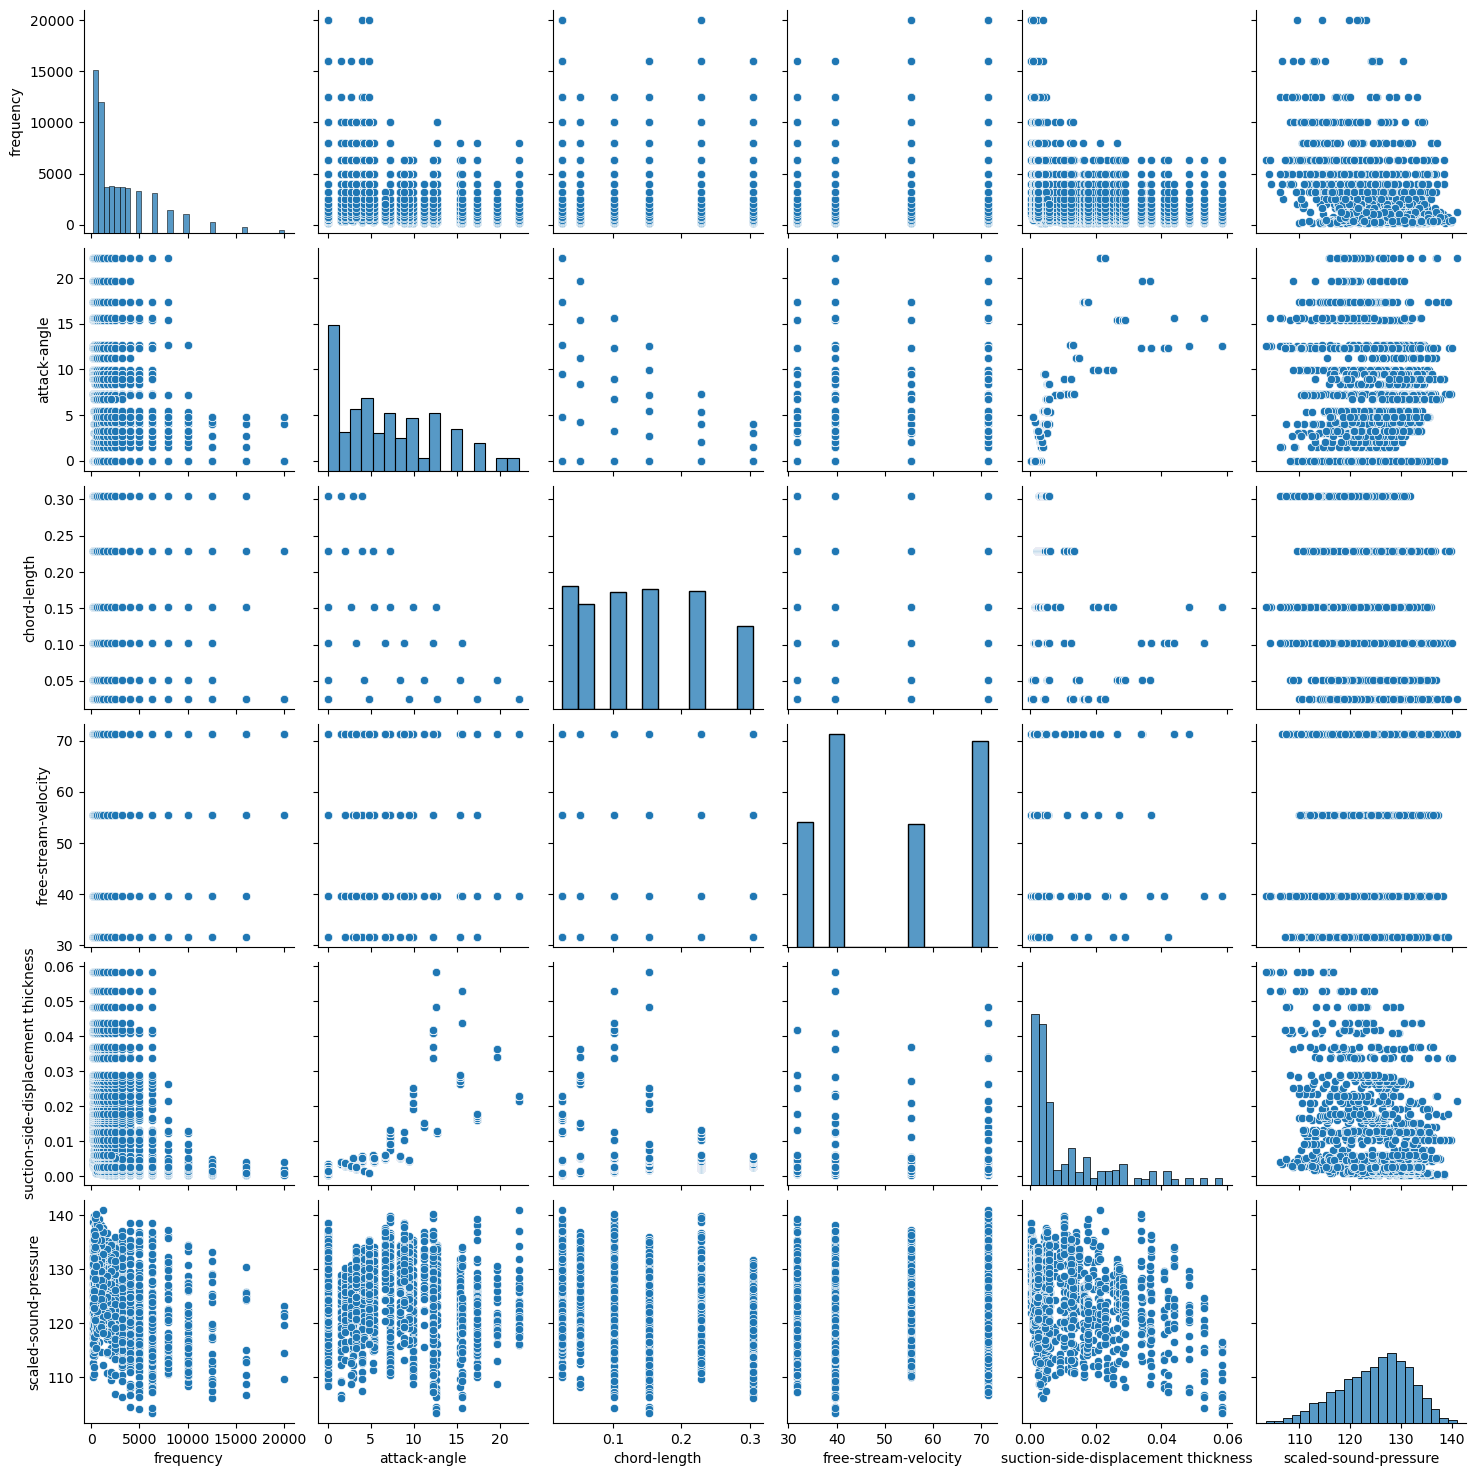

In [6]:
sns.pairplot(aero_df)

### Check Data

In [7]:
aero_df.isnull().sum(axis=0)

frequency                              0
attack-angle                           0
chord-length                           0
free-stream-velocity                   0
suction-side-displacement thickness    0
scaled-sound-pressure                  0
dtype: int64

### Create Data Sets

In [8]:
X = aero_df.drop('scaled-sound-pressure', axis=1)
y = aero_df['scaled-sound-pressure']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=1978)

### Create Basic Linear Regression Model - No Scaling

In [9]:
basic_model = LinearRegression()

In [10]:
basic_log = basic_model.fit(X_train, y_train)

In [11]:
basic_pred = basic_model.predict(X_test)

### Basic Model Scores

In [12]:
basic_score = r2_score(y_test, basic_pred)

In [13]:
print('R2 Score for Basic Model: ',np.round(basic_score, 2))

R2 Score for Basic Model:  0.49


### Standardize Data

In [14]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Create Model 1 - TensorFlow

In [15]:
t_model = keras.Sequential()
t_model.add(layers.Dense(32, activation='relu'))
t_model.add(layers.Dense(1))
t_model.compile(optimizer='adam',loss='mse')

### Train Model 1

In [16]:
tf.random.set_seed(2009)
t_model.fit(x=X_train,y=y_train,batch_size=128,epochs=150,validation_data=(X_test,y_test))

Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 15555.9385 - val_loss: 15678.5215
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15521.0684 - val_loss: 15642.6777
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15484.8340 - val_loss: 15604.9668
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15446.2500 - val_loss: 15564.4639
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15404.5820 - val_loss: 15520.5352
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 15359.0928 - val_loss: 15472.4580
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15308.9482 - val_loss: 15419.2656
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 15253.3525 - val_loss: 15360.1426
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15191.6406 - val_loss: 15294.0596
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15123.0254 - val_loss: 15220.3984
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15046.84

### Evaluate Model 1

In [17]:
y_pred = t_model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [18]:
'The mean square error is {0:.4f}'.format(mean_squared_error(y_test,y_pred))

'The mean square error is 942.7563'

In [19]:
'The root of mean square error is {0:.4f}'.format(np.sqrt(mean_squared_error(y_test, y_pred)))

'The root of mean square error is 30.7043'

In [20]:
'The mean absolute error is {0:.4f}'.format(mean_absolute_error(y_test,y_pred))

'The mean absolute error is 25.3087'

### Improve Model 1

In [21]:
t_model = keras.Sequential()
t_model.add(layers.Dense(128, activation='relu'))
t_model.add(layers.Dense(1))
t_model.compile(optimizer='adam',loss='mse')

### Re-train Model 1

In [22]:
tf.random.set_seed(2009)
t_model.fit(x=X_train,y=y_train,batch_size=128,epochs=150,validation_data=(X_test,y_test))

Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 15590.4990 - val_loss: 15697.7676
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15531.4521 - val_loss: 15634.2109
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15464.2891 - val_loss: 15559.3555
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15383.9883 - val_loss: 15468.5566
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15286.2344 - val_loss: 15357.6416
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15167.3145 - val_loss: 15224.4238
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 15026.2197 - val_loss: 15069.2363
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14863.9248 - val_loss: 14893.2920
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14681.5625 - val_loss: 14697.5781
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 14479.7090 - val_loss: 14482.1025
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14258.19

### Re-evaluate Model 1

In [23]:
y_pred = t_model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [24]:
'The new mean square error is {0:.4f}'.format(mean_squared_error(y_test,y_pred))

'The new mean square error is 578.4931'

In [25]:
'The root of mean square error is {0:.4f}'.format(np.sqrt(mean_squared_error(y_test, y_pred)))

'The root of mean square error is 24.0519'

In [26]:
'The mean absolute error is {0:.4f}'.format(mean_absolute_error(y_test,y_pred))

'The mean absolute error is 19.7036'

### Model 2 - PyTorch

### Convert data for PyTorch

In [27]:
X_train = torch.tensor(X_train.astype(np.float32))
y_train = torch.tensor(y_train.values.astype(np.float32).reshape(-1,1))

In [28]:
input_size = X_train.shape[1]
output_size = y_train.shape[1]
#specify the number of neuron for the first layer
hidden_size = 64
print(input_size)
print(output_size)

5
1


In [29]:
# define the child module class derivated from parent class of torch.nn.Module)
class LinearRegressionModel(torch.nn.Module):
    #define the constructor
    def __init__(self, input_size, hidden_size, output_size):
        super(LinearRegressionModel, self).__init__()
        self.hidden = torch.nn.Linear(input_size, hidden_size)  
        self.predict = torch.nn.Linear(hidden_size, output_size)  
    #overife the forward function in this child class
    def forward(self, x):
        x = F.relu(self.hidden(x))     
        y_pred = self.predict(x)            
        return y_pred

### Create Model 2

In [30]:
py_model = LinearRegressionModel(input_size, hidden_size, output_size)

In [31]:
l = nn.MSELoss()

In [ ]:
optimizer = torch.optim.Adam(py_model.parameters(), lr=0.05)

In [ ]:
#fix the random seeds for troch and np
torch.manual_seed(1)
np.random.seed(0)

#set the number of epochs
num_epochs = 150
for epoch in range(num_epochs):
    #forward pass
    y_pred = py_model(X_train.requires_grad_())

    #calculate the loss
    loss= l(y_pred, y_train)
    #Set the gradients to be zero
    optimizer.zero_grad()
    
    #backward pass: calculate gradients
    loss.backward()

    #update the weights
    optimizer.step()
  
    print('epoch {0}, loss:{1:.4f}'.format(epoch, loss.item()))

### Evaluate Model 2

In [ ]:
#convert numpy to tensor
X_test = torch.from_numpy(X_test.astype(np.float32))
#Stop tracking the gradient by calling detach since we don't use it anymore
y_pred = py_model(X_test).detach().numpy()

In [ ]:
'The mean square error is {0:.4f}'.format(mean_squared_error(y_test,y_pred))

In [ ]:
'The root of mean square error is {0:.4f}'.format(np.sqrt(mean_squared_error(y_test, y_pred)))

In [ ]:
'The mean absolute error is {0:.4f}'.format(mean_absolute_error(y_test,y_pred))

### Improve Model 2

In [ ]:
input_size = X_train.shape[1]
output_size = y_train.shape[1]
#specify the number of neuron for the first layer
hidden_size = 128
print(input_size)
print(output_size)

In [ ]:
py_model = LinearRegressionModel(input_size, hidden_size, output_size)

In [ ]:
l = nn.MSELoss()

In [ ]:
optimizer = torch.optim.Adam(py_model.parameters(), lr=0.05)

In [ ]:
#fix the random seeds for troch and np
torch.manual_seed(1)
np.random.seed(0)

#set the number of epochs
num_epochs = 100
for epoch in range(num_epochs):
    #forward pass
    y_pred = py_model(X_train.requires_grad_())

    #calculate the loss
    loss= l(y_pred, y_train)
    #Set the gradients to be zero
    optimizer.zero_grad()
    
    #backward pass: calculate gradients
    loss.backward()

    #update the weights
    optimizer.step()
  
    print('epoch {0}, loss:{1:.4f}'.format(epoch, loss.item()))

### Re-evaluate Model 2

In [ ]:
y_pred = py_model(X_test).detach().numpy()

In [ ]:
'The mean square error is {0:.4f}'.format(mean_squared_error(y_test,y_pred))

In [ ]:
'The root of mean square error is {0:.4f}'.format(np.sqrt(mean_squared_error(y_test, y_pred)))

In [ ]:
'The mean absolute error is {0:.4f}'.format(mean_absolute_error(y_test,y_pred))